In [75]:
# # VAR Spillover Bond Trading Strategy
# **Idea:** Use a VAR model on daily yield changes across countries to
# forecast next-day's yield move for a target country.  If yields are
# predicted to *fall* → buy the bond (price goes up).  If yields are
# predicted to *rise* → sell / stay in cash.

# %% Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from retrieve.get_data import get_yield
from statsmodels.tsa.api import VAR

In [76]:
# %% ── 1. LOAD DATA ──────────────────────────────────────────────────
term = 5  # 5-year bond
raw_yields = get_yield(term, freq="W-FRI") / 100  # convert from percentage (4.5) to decimal (0.045)

# Bond price from yield:  P = 100 / (1 + y)^term
bond_prices = 100 / ((1 + raw_yields) ** term)

# Daily yield *changes* (what the VAR models)
yield_changes = raw_yields.diff().dropna()

# Lag any country whose market closes AFTER Australia.
# PX_last is stamped by calendar date, but AUS closes ~6:30 AM GMT.
# Anything closing later on the same date isn't known until the next
# AUS trading day, so we shift those columns by 1.
#CLOSES_AFTER_AUS = ["US", "GER", "UK", "FRA", "SWITZ", "MEXICO", "BRAZIL"]

#for col in CLOSES_AFTER_AUS:
    #if col in yield_changes.columns:
        #yield_changes[col] = yield_changes[col].shift(1)


In [77]:

# %% ── 2. STRATEGY SETTINGS ──────────────────────────────────────────
TARGET = "AUS"              # country whose bond we trade
VAR_LAGS = 3                # number of lags in the VAR (chosen via AIC)
VOL_FILTER = 0.5            # only trade if |forecast| > VOL_FILTER × rolling σ
VOL_LOOKBACK = 104          # rolling window for σ  (104 trading weeks ≈ 2 years)
TCOST_BPS = 0             # bid-ask spread cost in basis points (one-way)
STARTING_CASH = 100_000.0   # initial portfolio value

In [78]:
# %% ── 3. TRAIN / TEST SPLIT ─────────────────────────────────────────
n = len(yield_changes)
split_idx = int(np.floor(0.70 * n))
split_date = yield_changes.index[split_idx]

# We need enough history for the VAR *and* the vol estimate
first_tradeable = max(split_idx, VAR_LAGS + 1, VOL_LOOKBACK + 1)

# Rolling volatility of the target's yield changes (noise filter)
rolling_vol = yield_changes[TARGET].rolling(VOL_LOOKBACK).std()

print(f"Total observations : {n}")
print(f"Train ends         : {split_date.date()}")
print(f"First trade date   : {yield_changes.index[first_tradeable].date()}")
print(f"Last date          : {yield_changes.index[-1].date()}")

Total observations : 737
Train ends         : 2021-12-17
First trade date   : 2021-12-17
Last date          : 2026-03-13


In [79]:
# %% ── 4. GENERATE SIGNALS ───────────────────────────────────────────
dates = yield_changes.index
records = []
coef_history = []  # store coefficients over time

for i in range(first_tradeable, len(dates) - 1):
    today = dates[i]

    train = yield_changes.loc[:today].replace([np.inf, -np.inf], np.nan).dropna()
    train = train.loc[:, train.nunique() > 1]

    min_rows = max(30, VAR_LAGS + 5, train.shape[1] * VAR_LAGS + 5)
    if len(train) < min_rows or TARGET not in train.columns:
        records.append(dict(date=today, forecast=np.nan, signal=0))
        continue

    try:
        res = VAR(train).fit(VAR_LAGS)
        fcast = res.forecast(train.values[-VAR_LAGS:], steps=1)[0]
        j = res.names.index(TARGET)
        forecast = fcast[j]

        # store the coefficients for the TARGET equation
        target_coefs = res.params.iloc[:, j]  # all coefficients for the TARGET equation
        coef_row = {"date": today}
        for name, val in target_coefs.items():
            coef_row[name] = val
        coef_history.append(coef_row)

    except Exception:
        records.append(dict(date=today, forecast=np.nan, signal=0))
        continue

    vol = rolling_vol.loc[today]
    if pd.isna(vol) or vol == 0 or abs(forecast) < VOL_FILTER * vol:
        signal = 0
    elif forecast < 0:
        signal = 1   # yields fall → buy bond
    else:
        signal = -1  # yields rise → short bond

    records.append(dict(date=today, forecast=forecast, signal=signal))

signals = pd.DataFrame(records).set_index("date")
coefs = pd.DataFrame(coef_history).set_index("date")

print(f"Signals generated  : {len(signals)}")

Signals generated  : 221


In [80]:
# %% ── 5. VAR COEFFICIENTS ───────────────────────────────────────────
# Average coefficients across the entire test period
# These tell you: for each lag of each country, how much does a 1bp
# move in that country's yield change predict for tomorrow's AUS change?
print(f"\n{'═' * 60}")
print(f"  Average VAR coefficients for {TARGET} equation")
print(f"{'═' * 60}")

mean_coefs = coefs.mean().sort_values(key=abs, ascending=False)
for name, val in mean_coefs.items():
    print(f"  {name:<20s} : {val:>10.4f}")

print(f"{'═' * 60}")


════════════════════════════════════════════════════════════
  Average VAR coefficients for AUS equation
════════════════════════════════════════════════════════════
  L1.JAPAN             :    -0.5960
  L2.JAPAN             :    -0.2531
  L1.AUS               :    -0.1848
  L1.US                :     0.1703
  L3.INDIA             :     0.0989
  L1.FRA               :     0.0890
  L3.FRA               :    -0.0765
  L3.US                :    -0.0761
  L1.GER               :     0.0698
  L2.UK                :     0.0593
  L3.AUS               :     0.0585
  L2.INDIA             :     0.0546
  L2.INDO              :    -0.0488
  L3.UK                :     0.0364
  L3.GER               :    -0.0364
  L2.FRA               :     0.0246
  L2.GER               :    -0.0241
  L3.BRAZIL            :     0.0234
  L2.SWITZ             :     0.0233
  L2.AUS               :     0.0135
  L1.INDIA             :    -0.0127
  L3.JAPAN             :    -0.0120
  L3.INDO              :    -0.0118
  L1.

In [81]:

# %% ── 7. PORTFOLIO SIMULATION ───────────────────────────────────────
allow_short = True
tcost_frac = TCOST_BPS / 10_000

portfolio_value = [STARTING_CASH]
portfolio_dates = [signals.index[0]]
prev_signal = 0

for i in range(len(signals) - 1):
    today = signals.index[i]
    tomorrow = signals.index[i + 1]
    sig = signals.loc[today, "signal"]

    price_today = bond_prices.loc[today, TARGET]
    price_tomorrow = bond_prices.loc[tomorrow, TARGET]
    price_return = (price_tomorrow - price_today) / price_today

    current_value = portfolio_value[-1]

    # pay the spread whenever the position changes
    if sig != prev_signal:
        current_value *= (1 - tcost_frac)
    prev_signal = sig

    if sig == 1:
        new_value = current_value * (1 + price_return)
    elif sig == -1 and allow_short:
        new_value = current_value * (1 - price_return)
    else:
        new_value = current_value

    portfolio_value.append(new_value)
    portfolio_dates.append(tomorrow)

portfolio = pd.Series(portfolio_value, index=portfolio_dates, name="portfolio")


In [82]:

# %% ── 8. PERFORMANCE METRICS ────────────────────────────────────────
total_return = portfolio.iloc[-1] / portfolio.iloc[0] - 1
daily_returns = portfolio.pct_change().dropna()
ann_sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(52) if daily_returns.std() > 0 else np.nan
cummax = portfolio.cummax()
drawdown = (portfolio - cummax) / cummax
max_dd = drawdown.min()

n_long = (signals["signal"] == 1).sum()
n_short = (signals["signal"] == -1).sum()
n_flat = (signals["signal"] == 0).sum()
pct_invested = 1 - n_flat / len(signals)
n_trades = (signals["signal"].diff().fillna(0) != 0).sum()
total_tcost = n_trades * tcost_frac

print(f"\n{'═' * 50}")
print(f"  Strategy Performance")
print(f"{'═' * 50}")
print(f"  Target country     : {TARGET}")
print(f"  Period             : {portfolio.index[0].date()} → {portfolio.index[-1].date()}")
print(f"  Starting value     : ${STARTING_CASH:>12,.2f}")
print(f"  Ending value       : ${portfolio.iloc[-1]:>12,.2f}")
print(f"  Total return       : {total_return:>11.2%}")
print(f"  Ann. Sharpe ratio  : {ann_sharpe:>11.2f}")
print(f"  Max drawdown       : {max_dd:>11.2%}")
print(f"  Weeks long / short  : {n_long} / {n_short}")
print(f"  Weeks flat (cash)   : {n_flat}")
print(f"  % time invested    : {pct_invested:.1%}")
print(f"  Round-trip trades  : {n_trades}")
print(f"  Total t-cost drag  : {total_tcost:.2%}")
print(f"{'═' * 50}")


══════════════════════════════════════════════════
  Strategy Performance
══════════════════════════════════════════════════
  Target country     : AUS
  Period             : 2021-12-17 → 2026-03-06
  Starting value     : $  100,000.00
  Ending value       : $  113,216.35
  Total return       :      13.22%
  Ann. Sharpe ratio  :        1.18
  Max drawdown       :      -1.80%
  Weeks long / short  : 16 / 15
  Weeks flat (cash)   : 190
  % time invested    : 14.0%
  Round-trip trades  : 50
  Total t-cost drag  : 0.00%
══════════════════════════════════════════════════


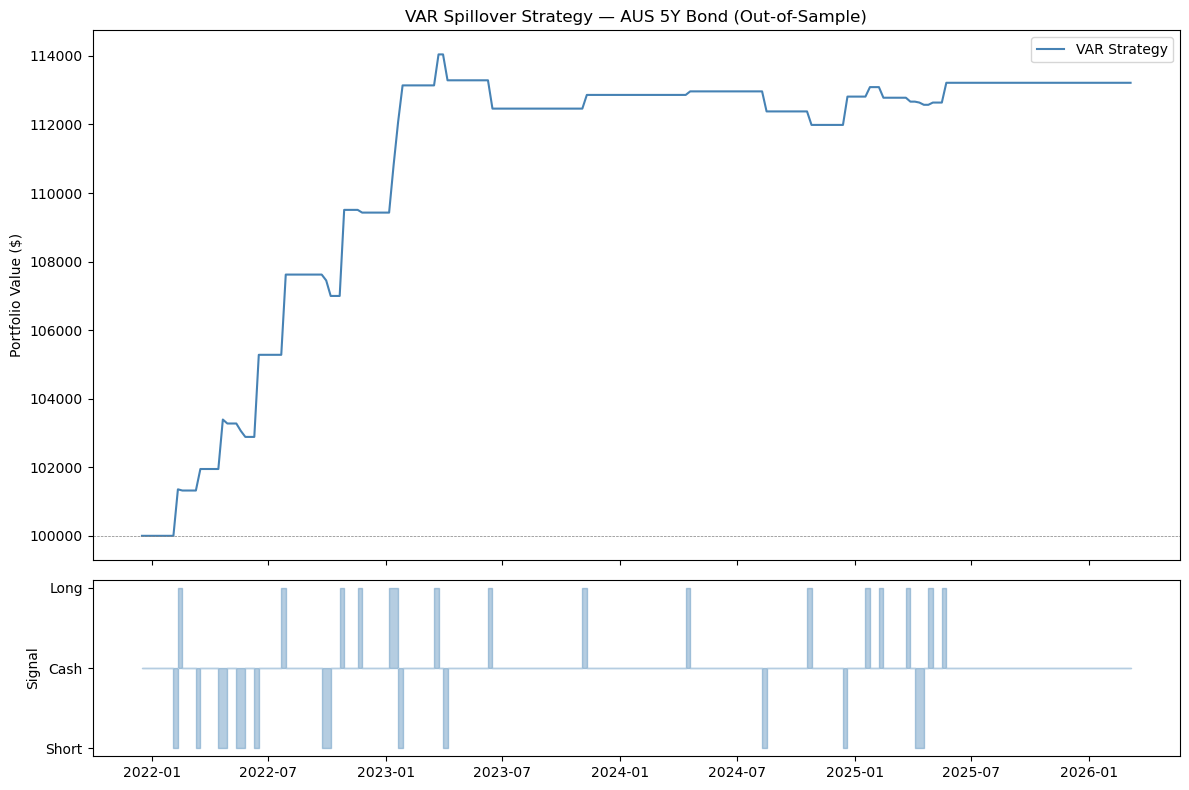

In [83]:
# %% ── 9. PLOT ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                         gridspec_kw={"height_ratios": [3, 1]})

# portfolio value
axes[0].plot(portfolio.index, portfolio.values, color="steelblue", label="VAR Strategy")
axes[0].axhline(STARTING_CASH, color="gray", ls="--", lw=0.5)
axes[0].set_ylabel("Portfolio Value ($)")
axes[0].set_title(f"VAR Spillover Strategy — {TARGET} {term}Y Bond (Out-of-Sample)")
axes[0].legend()

# signal timeline
axes[1].fill_between(signals.index, signals["signal"], step="post",
                     alpha=0.4, color="steelblue")
axes[1].set_ylabel("Signal")
axes[1].set_yticks([-1, 0, 1])
axes[1].set_yticklabels(["Short", "Cash", "Long"])

plt.tight_layout()
plt.show()